# Weighted Least Squares Fitting for Spheroid and Network Phenotypes
In modeling the phenotypic evolution of cancer cells, particularly the transition from spheroid to network structures, it is essential to accurately capture the experimental dynamics observed over time. This study employs **Weighted Least Squares (WLS)** fitting to model and parameterize concentration data derived from both spheroid and network phenotypes. Unlike Ordinary Least Squares (OLS), WLS accounts for heteroscedasticity in the data—i.e., non-uniform variances across observations—by assigning weights inversely proportional to the variance of each data point.

Given that the measurement uncertainties differ between the spheroid and network datasets—reflected in their respective standard deviations—we adopt a differential weighting scheme in the WLS fitting process. Data points with lower variance (i.e., higher confidence) are assigned greater influence in the fitting, while those with higher variance contribute less to the overall model optimization. This allows us to more accurately estimate model parameters and improve the robustness of our simulation results.

By using a variance-aware fitting approach, we aim to uncover mechanistically meaningful parameters that govern the behavior of these two phenotypic states under two varying experimental conditions. This will not only enhances the biological fidelity of the model but also enables more precise prediction and analysis of phenotypic transitions in cancer invasion.

#### Mathematical Formulation of Weighted Least Squares for Spheroid and Network Data

Let:

- $y_i^{(s)}$ be the observed spheroid concentration at time $t_i$
- $y_j^{(n)}$ be the observed network concentration at time $t_j$
- $f(t; \boldsymbol{\theta})$ be the model prediction function parameterized by $\boldsymbol{\theta}$
- $\sigma_i^{(s)}$ and $\sigma_j^{(n)}$ be the standard deviations (errors) of spheroid and network observations, respectively

We define the **weighted least squares objective function** as:

$$
\min_{\boldsymbol{\theta}} \left\{ 
\sum_{i=1}^{N_s} \left( \frac{y_i^{(s)} - f(t_i; \boldsymbol{\theta})}{\sigma_i^{(s)}} \right)^2 
+ 
\sum_{j=1}^{N_n} \left( \frac{y_j^{(n)} - f(t_j; \boldsymbol{\theta})}{\sigma_j^{(n)}} \right)^2 
\right\}
$$

Equivalently, using weights 
$w_i^{(s)} = \frac{1}{\left(\sigma_i^{(s)}\right)^2}$ 
and 
$w_j^{(n)} = \frac{1}{\left(\sigma_j^{(n)}\right)^2}$, we write:

$$
\min_{\boldsymbol{\theta}} \left\{
\sum_{i=1}^{N_s} w_i^{(s)} \cdot \left( y_i^{(s)} - f(t_i; \boldsymbol{\theta}) \right)^2 
+ 
\sum_{j=1}^{N_n} w_j^{(n)} \cdot \left( y_j^{(n)} - f(t_j; \boldsymbol{\theta}) \right)^2
\right\}
$$

This approach allows the model to be calibrated with greater sensitivity to the more reliable data points, improving parameter estimation and biological interpretability across both phenotypes.


#### Load packages for the data analysis:

In [1]:
import os
import pandas as pd
pd.set_option("display.max_rows", 2000)
pd.set_option("display.max_columns", 2000)
import numpy as np
import matplotlib.pyplot as plt
import requests
from requests.auth import HTTPBasicAuth
from scipy.spatial.distance import pdist

#### Access my private bitbucket repository:

#### test url

In [2]:
# Replace with your actual credential if different from mine
username = "TBENSON2"
app_password = "ATBByNQWP9s9VnHvN4bME36PT6ybBC311519"
repo_slug = "cellinvasionphenotype"
workspace = "Temitope746"
branch = "main"
file_path1 = "Bayesian_Optimization_data/network_1000_15_005/cell_typeposition1.csv"  # Exact path to CSV in the repo
file_path2 = "Bayesian_Optimization_data/spheroid_1000_10_005/cell_typeposition1.csv"

In [3]:
test_url = f"https://api.bitbucket.org/2.0/user"
test = requests.get(test_url, auth=HTTPBasicAuth(username, app_password))
print(test.status_code)
print(test.json() if test.status_code == 200 else test.text)

200
{'display_name': 'Temitope O. Benson', 'links': {'self': {'href': 'https://api.bitbucket.org/2.0/users/%7Bac4f5b71-2429-46f9-915b-65109beff91d%7D'}, 'avatar': {'href': 'https://secure.gravatar.com/avatar/d5a8461c338260eb4f5b38cc9d03f733?d=https%3A%2F%2Favatar-management--avatars.us-west-2.prod.public.atl-paas.net%2Finitials%2FTB-1.png'}, 'repositories': {'href': 'https://api.bitbucket.org/2.0/repositories/%7Bac4f5b71-2429-46f9-915b-65109beff91d%7D'}, 'snippets': {'href': 'https://api.bitbucket.org/2.0/snippets/%7Bac4f5b71-2429-46f9-915b-65109beff91d%7D'}, 'html': {'href': 'https://bitbucket.org/%7Bac4f5b71-2429-46f9-915b-65109beff91d%7D/'}, 'hooks': {'href': 'https://api.bitbucket.org/2.0/workspaces/%7Bac4f5b71-2429-46f9-915b-65109beff91d%7D/hooks'}}, 'created_on': '2024-01-02T15:38:35.086663+00:00', 'type': 'user', 'uuid': '{ac4f5b71-2429-46f9-915b-65109beff91d}', 'has_2fa_enabled': None, 'username': 'tbenson2', 'is_staff': False, 'account_id': '712020:db9853ee-626a-4a5d-a2e3-297b

In [4]:
# Build URL
url1 = f"https://api.bitbucket.org/2.0/repositories/{workspace}/{repo_slug}/src/{branch}/{file_path1}"
url2 = f"https://api.bitbucket.org/2.0/repositories/{workspace}/{repo_slug}/src/{branch}/{file_path2}"

response1 = requests.get(url1, auth=HTTPBasicAuth(username, app_password))
response2 = requests.get(url2, auth=HTTPBasicAuth(username, app_password))

# Save and read into pandas for the network sample
if response1.status_code == 200:
    with open("network.csv", "wb") as f1:
        f1.write(response1.content)
    df1 = pd.read_csv("network.csv")
    print(df1.head())
else:
    print(f"Error {response1.status_code}: {response1.text}")



# Save and read into pandas for the spheroid sample
if response2.status_code == 200:
    with open("spheroid.csv", "wb") as f2:
        f2.write(response2.content)
    df2 = pd.read_csv("spheroid.csv")
    print(df2.head())
else:
    print(f"Error {response2.status_code}: {response2.text}")

   mcs  cellid  cellType           x          y
0    0       1         2  100.074627  99.970149
1    1       1         2   99.774194  99.741935
2    2       1         2   99.793103  99.655172
3    3       1         2   99.509434  99.566038
4    4       1         2   99.620000  99.580000
   mcs  cellid  cellType           x           y
0    0       1         1  100.000000  100.000000
1    1       1         1  100.187500   99.984375
2    2       1         1  100.114754  100.098361
3    3       1         1  100.056604  100.132075
4    4       1         1  100.039216  100.039216


In [5]:
df1[df1["cellid"] ==2].head()
#df1.head(100)

,mcs,cellid,cellType,x,y
806,805,2,2,118.048387,95.903226
808,806,2,2,118.157895,95.859649
810,807,2,2,117.916667,95.875000
812,808,2,2,117.355556,95.933333
814,809,2,2,117.146341,95.634146


#### Extract and plot distances for a single network and spheroid csv

In [6]:
def extract_and_plot_distances(path, label=""):
    # Load and preprocess CSV
    df = pd.read_csv(path)
    df.columns = df.columns.str.strip().str.lower()
    df = df.sort_values('mcs')
    pixelScaledDistance = 2

    # Handle missing columns
    if 'cellid' not in df.columns:
        df['cellid'] = df.groupby('mcs').cumcount()
        print("`cellid` column missing. Assigned unique ID per row.")

    required_columns = {'x', 'y', 'mcs', 'cellid'}
    if not required_columns.issubset(df.columns):
        missing = required_columns - set(df.columns)
        raise ValueError(f"Still missing required columns in file: {path} — {missing}")

    # Convert MCS to hours
    df['hours'] = df['mcs'] * 0.024

    # Reference cell for dist_to_cell1
    ref_x, ref_y = df.iloc[0][['x', 'y']].values

    # First appearance of each cellid
    first_positions = df.sort_values('mcs').groupby('cellid').first()[['x', 'y']]
    

    # 1. Compute dist_self
    df['dist_self'] = df.apply(
        lambda row: pixelScaledDistance * np.sqrt(
            (row['x'] - first_positions.loc[row['cellid'], 'x'])**2 +
            (row['y'] - first_positions.loc[row['cellid'], 'y'])**2),
        axis=1
    )

    # 2. Compute dist_to_cell1
    df['dist_to_cell1'] = pixelScaledDistance * np.sqrt((df['x'] - ref_x)**2 + (df['y'] - ref_y)**2)

    # 3. Compute max_pairwise_dist per MCS
    max_pairwise_by_mcs = {}
    for mcs_val in df['mcs'].unique():
        coords = df[df['mcs'] == mcs_val][['x', 'y']].to_numpy()
        max_pairwise = np.max(pdist(coords)) if coords.shape[0] > 1 else 0
        max_pairwise_by_mcs[mcs_val] = pixelScaledDistance * max_pairwise

    df['max_pairwise_dist'] = df['mcs'].map(max_pairwise_by_mcs)

    # Group by hours instead of MCS
    grouped = df.groupby('hours')[['dist_self', 'dist_to_cell1', 'max_pairwise_dist']].max()

    # Plotting
    plt.figure(figsize=(12, 6))
    plt.plot(grouped.index, grouped['dist_self'], label='Dist Self (per cellid)', linewidth=2)
    plt.plot(grouped.index, grouped['dist_to_cell1'], label='Dist to First Cell', linewidth=2)
    plt.plot(grouped.index, grouped['max_pairwise_dist'], label='Max Pairwise Dist', linewidth=2)
    plt.title(f'Distance Metrics Over Time (Hours) - {label}')
    plt.xlabel('Time (Hours)')
    plt.ylabel('Cell invasion')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return grouped, df

#### Sample usage for dataframe visualization:

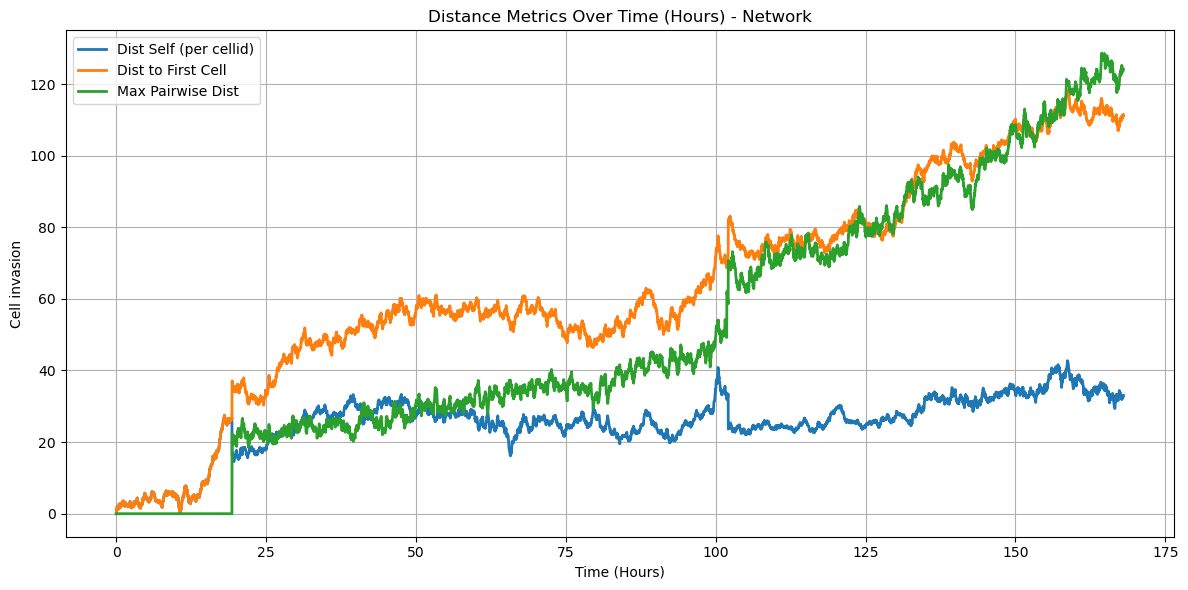

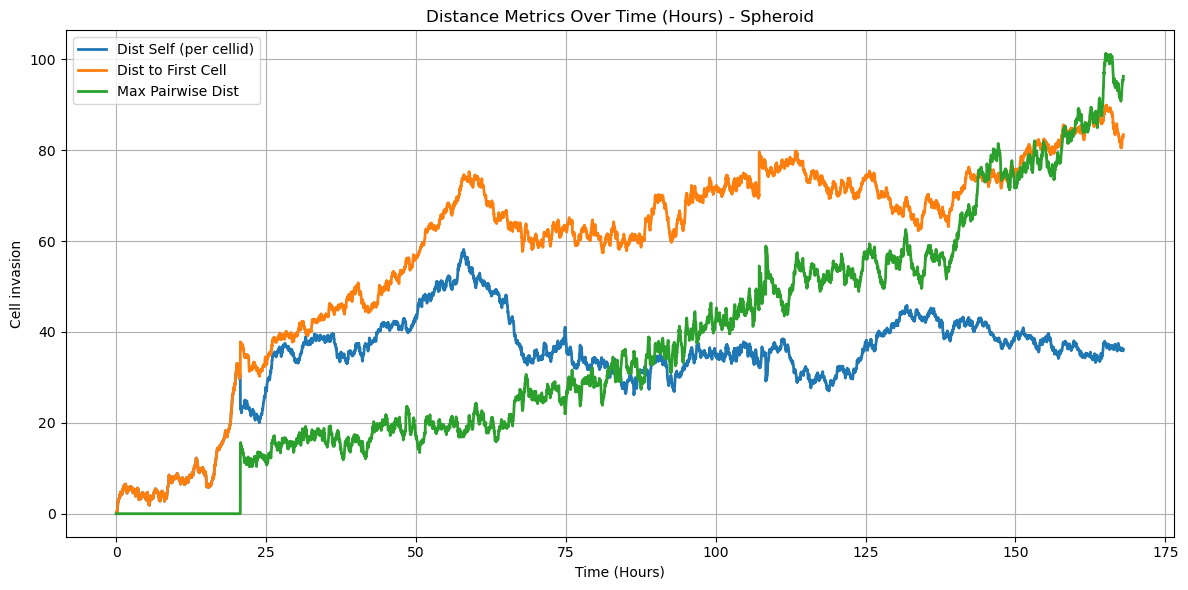

In [7]:
# sample usage for dataframe visualization for the whole simulation period:
network_df, full_df = extract_and_plot_distances("network.csv", label="Network")
spheroid_df, df  = extract_and_plot_distances("spheroid.csv", label="Spheroid")

#### Extract and plot the distances for 60 hours for the experimental data

In [8]:
# Experimental Data
network_days = np.array([12, 24, 36, 48, 60])
network_conc = np.array([7.41, 11.88, 18.53, 30.42, 35.91])
network_error = np.array([2.43, 2.43, 5.37, 6.52, 7.92])

spheroid_days = np.array([12, 24, 36, 48, 60])
spheroid_conc = np.array([5.24, 8.56, 11.50, 13.67, 13.42])
spheroid_error = np.array([0.77, 1.92, 1.79, 1.79, 1.79])

# -------------------------
# Function
# -------------------------
def extract_and_plot_distances(path, label, exp_days, exp_conc, exp_error):
    df = pd.read_csv(path)
    df.columns = df.columns.str.strip().str.lower()
    df = df.sort_values('mcs')

    required_columns = {'x', 'y', 'mcs', 'cellid'}
    if not required_columns.issubset(df.columns):
        missing = required_columns - set(df.columns)
        raise ValueError(f"Missing required columns in file: {path} — {missing}")

    # Reference point for dist_to_cell1
    ref_x, ref_y = df.iloc[0][['x', 'y']].values

    # First appearance per cellid for dist_self
    first_positions = df.sort_values('mcs').groupby('cellid').first()[['x', 'y']]

    # Compute distances
    df['dist_self'] = df.apply(lambda row: 2 * np.linalg.norm([
        row['x'] - first_positions.loc[row['cellid'], 'x'],
        row['y'] - first_positions.loc[row['cellid'], 'y']]), axis=1)

    df['dist_to_cell1'] = 2 * np.sqrt((df['x'] - ref_x)**2 + (df['y'] - ref_y)**2)

    # Max pairwise per MCS
    max_pairwise_by_mcs = {}
    for mcs_val in df['mcs'].unique():
        coords = df[df['mcs'] == mcs_val][['x', 'y']].to_numpy()
        max_pairwise = np.max(pdist(coords)) if coords.shape[0] > 1 else 0
        max_pairwise_by_mcs[mcs_val] = 2 * max_pairwise

    df['max_pairwise'] = df['mcs'].map(max_pairwise_by_mcs)
    

    # Group by MCS
    grouped = df.groupby('mcs')[['dist_self', 'dist_to_cell1', 'max_pairwise']].max()

    # Convert MCS to hours
    grouped['hours'] = grouped.index * 0.024

    # Truncate to 60 hours
    grouped = grouped[grouped['hours'] <= 60]


    ##### Find where dist_self not equal dist_to_cell1 ######
    epsilon = 1e-3  # tolerance for equality
    unequal_mask = np.abs(grouped['dist_self'] - grouped['dist_to_cell1']) > epsilon
    unequal_hours = grouped['hours'][unequal_mask]

    ##### Group consecutive hours into ranges
    from itertools import groupby
    from operator import itemgetter

    ranges = []
    hours_list = unequal_hours.tolist()
    for k, g in groupby(enumerate(hours_list), lambda ix: ix[0] - ix[1]):
        group = list(map(itemgetter(1), g))
        if group:
            ranges.append((group[0], group[-1]))


    # Plotting
    plt.figure(figsize=(12, 6))
    plt.plot(grouped['hours'], grouped['dist_self'], label='Dist Self (per cellid)', linewidth=2)
    plt.plot(grouped['hours'], grouped['dist_to_cell1'], label='Dist to First Cell', linewidth=2)
    plt.plot(grouped['hours'], grouped['max_pairwise'], label='Max Pairwise Dist', linewidth=2)


    ###### Highlight unequal ranges
    for start, end in ranges:
        plt.axvspan(start, end, color='orange', alpha=0.2, label='Dist Mismatch' if start == ranges[0][0] else "")

    # Experimental data (days = hours)
    plt.errorbar(exp_days, exp_conc, yerr=exp_error, fmt='o', capsize=5,
                 label=f'Experimental Data ({label})', color='black', markersize=6, linewidth=2)

    plt.title(f'Distance Metrics vs Time (Hours) – {label}')
    plt.xlabel('Time (Hours)')
    plt.ylabel('Cell invasion')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return grouped, df

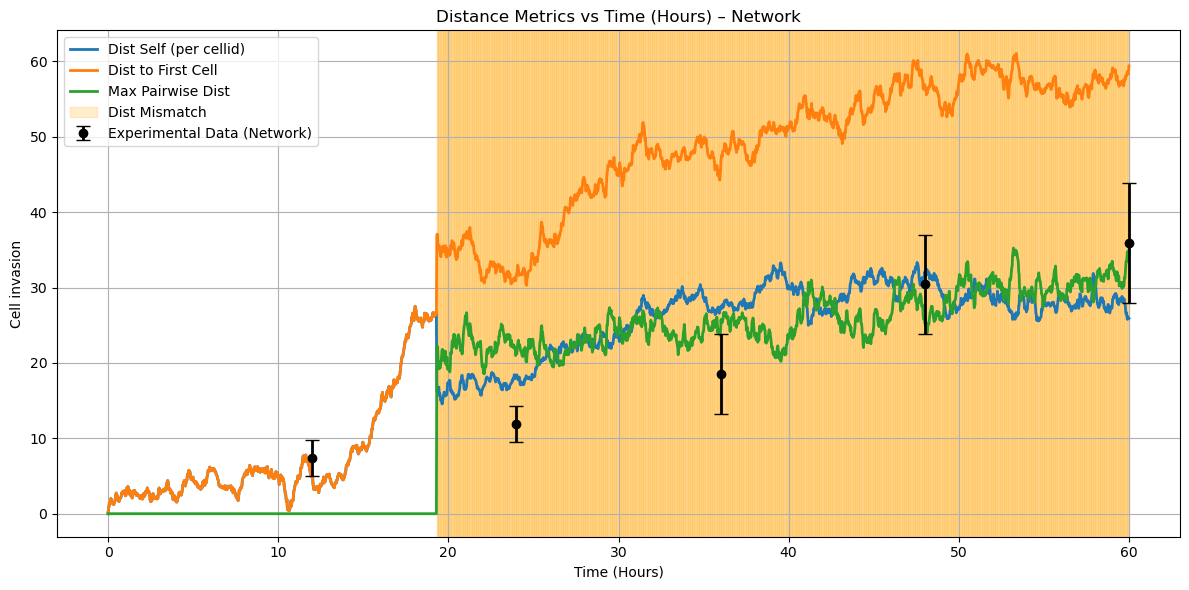

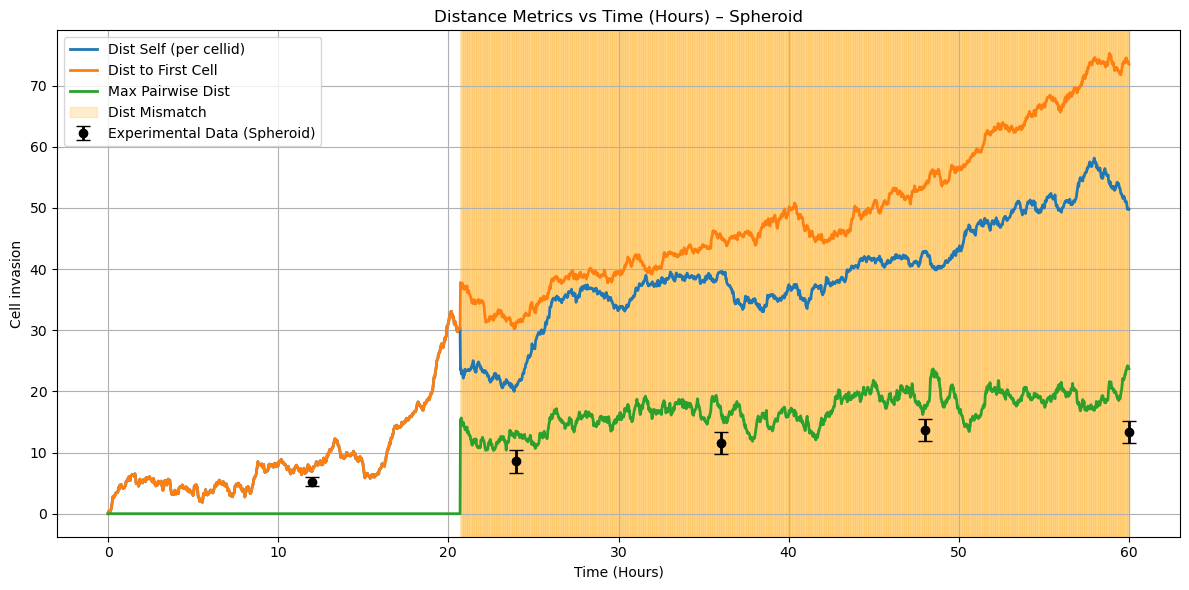

In [9]:
# -------------------------
# Run for Network and Spheroid
# -------------------------
network_df_plot = extract_and_plot_distances("network.csv", label="Network",
                                        exp_days=network_days, exp_conc=network_conc, exp_error=network_error)

spheroid_df_plot = extract_and_plot_distances("spheroid.csv", label="Spheroid",
                                         exp_days=spheroid_days, exp_conc=spheroid_conc, exp_error=spheroid_error)

# Sum of Square Error (SSE)

In [10]:
def get_group_mean_std(all_grouped_dfs, metric):
    dfs = pd.concat(all_grouped_dfs, keys=range(len(all_grouped_dfs)))
    mean_df = dfs.groupby(level=1).mean()
    std_df = dfs.groupby(level=1).std()
    return mean_df, std_df

def compute_sse(sim_mean_df, experimental_data, metric):
    exp_times = experimental_data['days']
    exp_values = experimental_data['concentration']
    sim_interp = np.interp(exp_times, sim_mean_df.index, sim_mean_df[metric])
    return np.sum((exp_values - sim_interp)**2)

## 📘 Detailed Analysis of Sum of Squared Error (SSE)

To quantitatively evaluate how well the simulation results match the experimental data, we compute the **Sum of Squared Errors (SSE)** for each distance metric:

- `dist_self`: distance of each cell from its original position
- `dist_to_cell1`: distance of each cell from the first cell
- `max_pairwise_dist`: maximum distance between any two cells

We do this at specific time points: **12, 24, 36, 48, and 60 hours**.

---

### 🔸 Mathematical Definition

Let:

- $t_i$: the $i$-th time point (in hours)
- $y_i$: the experimental observation (e.g., cell invasion concentration) at time $t_i$
- $\hat{y}(t_i)$: the simulation result (mean of a distance metric) at time $t_i$
- $n$: number of time points (in this case, $n = 5$)

The **Sum of Squared Error (SSE)** is calculated as:

$$
\text{SSE} = \sum_{i=1}^{n} \left( y_i - \hat{y}(t_i) \right)^2
$$

---

### 🔸 How $\hat{y}(t_i)$ is Obtained

Since the simulation outputs are provided at many time points (via MCS, later converted to hours), and may not align perfectly with the experimental time points $t_i$, we **linearly interpolate** the simulation values to estimate $\hat{y}(t_i)$.

This is performed using:

```python
np.interp(exp_times, sim_times, sim_values)


In [11]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
from requests.auth import HTTPBasicAuth
from scipy.spatial.distance import pdist

# --- Configuration ---
pixelScaledDistance = 2
MCS_TO_HOURS = 0.024
NUM_FILES_PER_FOLDER = 20

# Bitbucket credentials and repo info
username = "TBENSON2"
app_password = "ATBByNQWP9s9VnHvN4bME36PT6ybBC311519"
repo_slug = "cellinvasionphenotype"
workspace = "Temitope746"
branch = "main"

# Some folders containing the simulation data
network_roots = ["network_1000_15_005", "network_500_10_005"]
spheroid_roots = ["spheroid_1000_15_005", "spheroid_500_10_005"]

# Experimental data for overlay
experimental_data = {
    "network": {
        "days": np.array([12, 24, 36, 48, 60]),
        "concentration": np.array([7.41, 11.88, 18.53, 30.42, 35.91]),
        "error": np.array([2.43, 2.43, 5.37, 6.52, 7.92])
    },
    "spheroid": {
        "days": np.array([12, 24, 36, 48, 60]),
        "concentration": np.array([5.24, 8.56, 11.50, 13.67, 13.42]),
        "error": np.array([0.77, 1.92, 1.79, 1.79, 1.79])
    }
}

# --- Helper Functions ---
def build_bitbucket_url(file_path):
    return f"https://api.bitbucket.org/2.0/repositories/{workspace}/{repo_slug}/src/{branch}/Bayesian_Optimization_data/{file_path}"

def fetch_csv(file_path, local_filename):
    url = build_bitbucket_url(file_path)
    try:
        response = requests.get(url, auth=HTTPBasicAuth(username, app_password))
        if response.status_code == 200:
            with open(local_filename, "wb") as f:
                f.write(response.content)
            return pd.read_csv(local_filename)
    except:
        pass
    return None

def compute_distances(df):
    df.columns = df.columns.str.strip().str.lower()
    df = df.sort_values('mcs')
    if 'cellid' not in df.columns:
        df['cellid'] = df.groupby('mcs').cumcount()
    df['hours'] = df['mcs'] * MCS_TO_HOURS
    ref_x, ref_y = df.iloc[0][['x', 'y']].values
    first_pos = df.groupby('cellid').first()[['x', 'y']]

    df['dist_self'] = df.apply(lambda row: pixelScaledDistance * np.linalg.norm([
        row['x'] - first_pos.loc[row['cellid'], 'x'],
        row['y'] - first_pos.loc[row['cellid'], 'y']]), axis=1)

    df['dist_to_cell1'] = pixelScaledDistance * np.sqrt((df['x'] - ref_x)**2 + (df['y'] - ref_y)**2)

    max_pairwise = {}
    for mcs in df['mcs'].unique():
        coords = df[df['mcs'] == mcs][['x', 'y']].to_numpy()
        max_dist = np.max(pdist(coords)) if coords.shape[0] > 1 else 0
        max_pairwise[mcs] = pixelScaledDistance * max_dist

    df['max_pairwise_dist'] = df['mcs'].map(max_pairwise)
    return df

def process_folder(folder_name):
    combined = []
    for i in range(1, NUM_FILES_PER_FOLDER + 1):
        path = f"{folder_name}/cell_typeposition{i}.csv"
        local_name = f"{folder_name.replace('/', '_')}_file{i}.csv"
        df = fetch_csv(path, local_name)
        if df is not None:
            df = compute_distances(df)
            grouped = df.groupby('hours')[['dist_self', 'dist_to_cell1', 'max_pairwise_dist']].max()
            grouped = grouped[grouped.index <= 60]
            combined.append(grouped)
    return combined

def get_group_mean_std(all_grouped_dfs, metric):
    dfs = pd.concat(all_grouped_dfs, keys=range(len(all_grouped_dfs)))
    mean_df = dfs.groupby(level=1).mean()
    std_df = dfs.groupby(level=1).std()
    return mean_df, std_df

def compute_sse(sim_mean_df, experimental_data, metric):
    exp_times = experimental_data['days']
    exp_values = experimental_data['concentration']
    sim_interp = np.interp(exp_times, sim_mean_df.index, sim_mean_df[metric])
    return np.sum((exp_values - sim_interp)**2)

# --- Main Execution ---
all_grouped_dfs = {"network": [], "spheroid": []}

for folder in network_roots:
    all_grouped_dfs["network"].extend(process_folder(folder))

for folder in spheroid_roots:
    all_grouped_dfs["spheroid"].extend(process_folder(folder))

metrics = ['dist_self', 'dist_to_cell1', 'max_pairwise_dist']
sse_summary = {}

for metric in metrics:
    for group in ['network', 'spheroid']:
        mean_df, std_df = get_group_mean_std(all_grouped_dfs[group], metric)
        sse = compute_sse(mean_df, experimental_data[group], metric)
        sse_summary[(group, metric)] = sse

# Determine best metric for each group
best_metrics_by_group = {}
for group in ['network', 'spheroid']:
    best = min([(metric, sse) for (grp, metric), sse in sse_summary.items() if grp == group], key=lambda x: x[1])
    best_metrics_by_group[group] = best

# Prepare DataFrame for display
sse_df = pd.DataFrame([
    {"Group": grp, "Metric": met, "SSE": val}
    for (grp, met), val in sse_summary.items()
])
sse_df = sse_df.sort_values(by=["Group", "SSE"])

sse_df

,Group,Metric,SSE
0,network,dist_self,113.866943
4,network,max_pairwise_dist,165.351193
2,network,dist_to_cell1,216.406459
5,spheroid,max_pairwise_dist,105.672363
1,spheroid,dist_self,245.220996
3,spheroid,dist_to_cell1,424.161684


### Explanation

Let:

- $\text{SSE}_{\text{network}}^{(m)}$: SSE for the network group using metric $m$  
- $\text{SSE}_{\text{spheroid}}^{(m)}$: SSE for the spheroid group using metric $m$  

Then the **total SSE** for metric $m$ is:

$$
\text{Total SSE}^{(m)} = \text{SSE}_{\text{network}}^{(m)} + \text{SSE}_{\text{spheroid}}^{(m)}
$$

We choose the best metric that minimizes this total SSE:

$$
\text{Best Metric} = \arg\min_{m \in \{\text{dist\_self},\ \text{dist\_to\_cell1},\ \text{max\_pairwise\_dist}\}} \text{Total SSE}^{(m)}
$$

---
**Result Interpretation:**  
The selected metric minimizes the total prediction error across both **network** and **spheroid** phenotypes, making it the most **robust** and **representative** distance metric for your comparative invasion modeling.


### To generate a DataFrame in python that for each one of the replicates stores the run name, replication number, its set of parameter values that we allow to vary between simulations, and the SSE for each replicate distinctly. We do this separately for spheroid and for network phenotype so as to enable us perform bayesian optimization with SSE (at the experimental time interval only) as our objective function.

In [12]:
# Experimental data for overlay
experimental_data = {
    "network": {
        "days": np.array([12, 24, 36, 48, 60]),
        "concentration": np.array([7.41, 11.88, 18.53, 30.42, 35.91]),
        "error": np.array([2.43, 2.43, 5.37, 6.52, 7.92])
    },
    "spheroid": {
        "days": np.array([12, 24, 36, 48, 60]),
        "concentration": np.array([5.24, 8.56, 11.50, 13.67, 13.42]),
        "error": np.array([0.77, 1.92, 1.79, 1.79, 1.79])
    }
}

# --- Helper Functions ---
def build_bitbucket_url(file_path):
    return f"https://api.bitbucket.org/2.0/repositories/{workspace}/{repo_slug}/src/{branch}/Bayesian_Optimization_data/{file_path}"

def fetch_csv(file_path, local_filename):
    """Fetch a CSV file from Bitbucket and save locally."""
    url = build_bitbucket_url(file_path)
    try:
        response = requests.get(url, auth=HTTPBasicAuth(username, app_password))
        if response.status_code == 200:
            with open(local_filename, "wb") as f:
                f.write(response.content)
            return pd.read_csv(local_filename)
    except Exception as e:
        print(f"⚠️ Error fetching {file_path}: {e}")
    return None

def load_parameters(folder_name):
    """Load the ParameterS.json file for the given simulation run (case-sensitive)."""
    param_path = f"{folder_name}/ParameterS.json"   # ✅ FIXED CAPITALIZATION
    url = build_bitbucket_url(param_path)
    print(f"📡 Fetching ParameterS.json from: {url}")  # Debug print
    response = requests.get(url, auth=HTTPBasicAuth(username, app_password))
    if response.status_code == 200:
        data = json.loads(response.content.decode('utf-8'))
        print(f"✅ Loaded parameters for {folder_name}: {data}")
        return data
    else:
        print(f"⚠️ Could not load ParameterS.json for {folder_name} (status {response.status_code})")
    return {}

def compute_max_distance(df):
    """Compute the max distance from the original cell (cell 1’s starting position) at each time point."""
    df.columns = df.columns.str.strip().str.lower()
    df = df.sort_values('mcs')
    if 'cellid' not in df.columns:
        df['cellid'] = df.groupby('mcs').cumcount()
    df['hours'] = df['mcs'] * MCS_TO_HOURS
    
    ref_x, ref_y = df.iloc[0][['x', 'y']].values
    df['dist_to_origin'] = pixelScaledDistance * np.sqrt((df['x'] - ref_x)**2 + (df['y'] - ref_y)**2)
    max_distances = df.groupby('hours')['dist_to_origin'].max()
    return max_distances[max_distances.index <= 60]

def process_folder(folder_name, group_name):
    """Process all files in a simulation folder and compute mean SSE across all 20 replicates."""
    sse_values = []
    for i in range(1, NUM_FILES_PER_FOLDER + 1):
        file_path = f"{folder_name}/cell_typeposition{i}.csv"
        local_name = f"{folder_name.replace('/', '_')}_file{i}.csv"
        df = fetch_csv(file_path, local_name)

        if df is not None:
            max_distances = compute_max_distance(df)
            exp_times = experimental_data[group_name]["days"]
            exp_values = experimental_data[group_name]["concentration"]
            sim_interp = np.interp(exp_times, max_distances.index, max_distances.values)
            sse = np.sum((exp_values - sim_interp)**2)
            sse_values.append(sse)

    run_sse = np.mean(sse_values) if len(sse_values) > 0 else np.nan
    return {"Group": group_name, "Run": folder_name, "SSE": run_sse}

# --- Main Execution ---
all_results = []

for group, roots in [("network", network_roots), ("spheroid", spheroid_roots)]:
    for folder in roots:
        all_results.append(process_folder(folder, group))

# Build dataframe of all runs
sse_df = pd.DataFrame(all_results)
print("---- SSE for each run ----")
print(sse_df)


---- SSE for each run ----
      Group                   Run          SSE
0   network   network_1000_15_005   969.897765
1   network    network_500_10_005   567.672673
2  spheroid  spheroid_1000_15_005  1114.058588
3  spheroid   spheroid_500_10_005   446.466557


In [13]:

# ✅ Find the best run for NETWORK and SPHEROID
best_network = sse_df[sse_df["Group"] == "network"].sort_values("SSE").iloc[0]
best_spheroid = sse_df[sse_df["Group"] == "spheroid"].sort_values("SSE").iloc[0]

# ✅ Load the ParameterS.json file for the BEST RUNS
network_params = load_parameters(best_network["Run"])
spheroid_params = load_parameters(best_spheroid["Run"])

# ✅ Build final clean DataFrame with ONLY the needed parameters
best_params_df = pd.DataFrame([
    {
        "Group": "network",
        "Run": best_network["Run"],
        "SSE": best_network["SSE"],
        "J_cc": network_params.get("J_cc", np.nan),
        "lambda": network_params.get("lambda", np.nan),
        "k": network_params.get("k", np.nan),
        "e": network_params.get("e", np.nan),
        "spheroid_init": network_params.get("spheroid_init", np.nan)
    },
    {
        "Group": "spheroid",
        "Run": best_spheroid["Run"],
        "SSE": best_spheroid["SSE"],
        "J_cc": spheroid_params.get("J_cc", np.nan),
        "lambda": spheroid_params.get("lambda", np.nan),
        "k": spheroid_params.get("k", np.nan),
        "e": spheroid_params.get("e", np.nan),
        "spheroid_init": spheroid_params.get("spheroid_init", np.nan)
    }
])

print("\n✅ Final Best Parameters DataFrame:")
print(best_params_df)


📡 Fetching ParameterS.json from: https://api.bitbucket.org/2.0/repositories/Temitope746/cellinvasionphenotype/src/main/Bayesian_Optimization_data/network_500_10_005/ParameterS.json


NameError: name 'json' is not defined

#### Parameter defnition

- *J_cc* : Cell-cell contact energy
- *lambda*: chemotaxis toward medium for each phenotype
- *k*: chemotaxis strength
- *e*: length constraints/ elongation
- *spheroid_init*: cell start with spheriod initialization

#### Run for each SSE at each MCS STEP

In [14]:
import os
import pandas as pd
import numpy as np
import requests
import json
from requests.auth import HTTPBasicAuth

# --- Configuration ---
pixelScaledDistance = 2
MCS_TO_HOURS = 0.024
NUM_FILES_PER_FOLDER = 20

# Bitbucket credentials and repo info
username = "TBENSON2"
app_password = "ATBByNQWP9s9VnHvN4bME36PT6ybBC311519"
repo_slug = "cellinvasionphenotype"
workspace = "Temitope746"
branch = "main"

# Folders containing the simulation data
network_roots = ["network_1000_25_01", "network_500_1_0001"]
spheroid_roots = ["spheroid_1000_25_01", "spheroid_500_1_0001"]

# Experimental data for overlay
experimental_data = {
    "network": {
        "days": np.array([12, 24, 36, 48, 60]),
        "concentration": np.array([7.41, 11.88, 18.53, 30.42, 35.91]),
        "error": np.array([2.43, 2.43, 5.37, 6.52, 7.92])
    },
    "spheroid": {
        "days": np.array([12, 24, 36, 48, 60]),
        "concentration": np.array([5.24, 8.56, 11.50, 13.67, 13.42]),
        "error": np.array([0.77, 1.92, 1.79, 1.79, 1.79])
    }
}

# --- Helper Functions ---
def build_bitbucket_url(file_path):
    return f"https://api.bitbucket.org/2.0/repositories/{workspace}/{repo_slug}/src/{branch}/Bayesian_Optimization_data/{file_path}"

def fetch_csv(file_path, local_filename):
    """Fetch a CSV file from Bitbucket and save locally."""
    url = build_bitbucket_url(file_path)
    try:
        response = requests.get(url, auth=HTTPBasicAuth(username, app_password))
        if response.status_code == 200:
            with open(local_filename, "wb") as f:
                f.write(response.content)
            return pd.read_csv(local_filename)
    except Exception as e:
        print(f"⚠️ Error fetching {file_path}: {e}")
    return None

def load_parameters(folder_name):
    """Load the ParameterS.json file for the given simulation run (case-sensitive)."""
    param_path = f"{folder_name}/ParameterS.json"   # ✅ FIXED CAPITALIZATION
    url = build_bitbucket_url(param_path)
    print(f"📡 Fetching ParameterS.json from: {url}")  # Debug print
    response = requests.get(url, auth=HTTPBasicAuth(username, app_password))
    if response.status_code == 200:
        data = json.loads(response.content.decode('utf-8'))
        print(f"✅ Loaded parameters for {folder_name}: {data}")
        return data
    else:
        print(f"⚠️ Could not load ParameterS.json for {folder_name} (status {response.status_code})")
    return {}

def compute_max_distance(df):
    """Compute the max distance from the original cell (cell 1’s starting position) at each time point."""
    df.columns = df.columns.str.strip().str.lower()
    df = df.sort_values('mcs')
    if 'cellid' not in df.columns:
        df['cellid'] = df.groupby('mcs').cumcount()
    df['hours'] = df['mcs'] * MCS_TO_HOURS
    
    ref_x, ref_y = df.iloc[0][['x', 'y']].values
    df['dist_to_origin'] = pixelScaledDistance * np.sqrt((df['x'] - ref_x)**2 + (df['y'] - ref_y)**2)
    max_distances = df.groupby('hours')['dist_to_origin'].max()
    return max_distances[max_distances.index <= 60]

def process_folder(folder_name, group_name):
    """Process all files in a simulation folder and compute mean SSE across all 20 replicates."""
    sse_values = []
    for i in range(1, NUM_FILES_PER_FOLDER + 1):
        file_path = f"{folder_name}/cell_typeposition{i}.csv"
        local_name = f"{folder_name.replace('/', '_')}_file{i}.csv"
        df = fetch_csv(file_path, local_name)

        if df is not None:
            max_distances = compute_max_distance(df)
            exp_times = experimental_data[group_name]["days"]
            exp_values = experimental_data[group_name]["concentration"]
            sim_interp = np.interp(exp_times, max_distances.index, max_distances.values)
            sse = np.sum((exp_values - sim_interp)**2)
            sse_values.append(sse)

    run_sse = np.mean(sse_values) if len(sse_values) > 0 else np.nan
    return {"Group": group_name, "Run": folder_name, "SSE": run_sse}

# --- Main Execution ---
all_results = []

for group, roots in [("network", network_roots), ("spheroid", spheroid_roots)]:
    for folder in roots:
        all_results.append(process_folder(folder, group))

# Build dataframe of all runs
sse_df = pd.DataFrame(all_results)
print("---- SSE for each run ----")
print(sse_df)


---- SSE for each run ----
      Group                  Run          SSE
0   network   network_1000_25_01  1852.039247
1   network   network_500_1_0001  1026.423957
2  spheroid  spheroid_1000_25_01  3358.780708
3  spheroid  spheroid_500_1_0001   111.289216


In [15]:
# ✅ Find the best run for NETWORK and SPHEROID
best_network = sse_df[sse_df["Group"] == "network"].sort_values("SSE").iloc[0]
best_spheroid = sse_df[sse_df["Group"] == "spheroid"].sort_values("SSE").iloc[0]

# ✅ Load the ParameterS.json file for the BEST RUNS
network_params = load_parameters(best_network["Run"])
spheroid_params = load_parameters(best_spheroid["Run"])

# ✅ Build final clean DataFrame with ONLY the needed parameters
best_params_df = pd.DataFrame([
    {
        "Group": "network",
        "Run": best_network["Run"],
        "SSE": best_network["SSE"],
        "J_cc": network_params.get("J_cc", np.nan),
        "lambda": network_params.get("lambda", np.nan),
        "k": network_params.get("k", np.nan),
        "e": network_params.get("e", np.nan),
        "spheroid_init": network_params.get("spheroid_init", np.nan)
    },
    {
        "Group": "spheroid",
        "Run": best_spheroid["Run"],
        "SSE": best_spheroid["SSE"],
        "J_cc": spheroid_params.get("J_cc", np.nan),
        "lambda": spheroid_params.get("lambda", np.nan),
        "k": spheroid_params.get("k", np.nan),
        "e": spheroid_params.get("e", np.nan),
        "spheroid_init": spheroid_params.get("spheroid_init", np.nan)
    }
])

print("\n✅ Final Best Parameters DataFrame:")
print(best_params_df)

📡 Fetching ParameterS.json from: https://api.bitbucket.org/2.0/repositories/Temitope746/cellinvasionphenotype/src/main/Bayesian_Optimization_data/network_500_1_0001/ParameterS.json
✅ Loaded parameters for network_500_1_0001: {'J_cc': 1, 'lambda': 500, 'k': 0.001, 'e': 1, 'spheroid_init': 0}
📡 Fetching ParameterS.json from: https://api.bitbucket.org/2.0/repositories/Temitope746/cellinvasionphenotype/src/main/Bayesian_Optimization_data/spheroid_500_1_0001/ParameterS.json
✅ Loaded parameters for spheroid_500_1_0001: {'J_cc': 1, 'lambda': 500, 'k': 0.001, 'e': 0, 'spheroid_init': 1}

✅ Final Best Parameters DataFrame:
      Group                  Run          SSE  J_cc  lambda      k  e  \
0   network   network_500_1_0001  1026.423957     1     500  0.001  1   
1  spheroid  spheroid_500_1_0001   111.289216     1     500  0.001  0   

   spheroid_init  
0              0  
1              1  


#### Parameter defnition

- *J_cc* : Cell-cell contact energy
- *lambda*: chemotaxis toward medium for each phenotype
- *k*: chemotaxis strength
- *e*: length constraints/ elongation
- *spheroid_init*: cell start with spheriod initialization

#### Rerun for each SSE at each MCS STEP

In [16]:
# === UPDATED SSE PER HOUR STEP (fixed paths + robust hour matching) ===
import os
import re
import json
import numpy as np
import pandas as pd
import requests
from requests.auth import HTTPBasicAuth

# ========= Config =========
pixelScaledDistance = 2
MCS_TO_HOURS = 0.024
BASE_DIR = "Bayesian_Optimization_data"   # root folder in repo

username = os.getenv("BB_USERNAME", "TBENSON2")
app_password = os.getenv("BB_APP_PASSWORD", "ATBByNQWP9s9VnHvN4bME36PT6ybBC311519")
repo_slug = os.getenv("BB_REPO", "cellinvasionphenotype")
workspace = os.getenv("BB_WORKSPACE", "Temitope746")
branch = os.getenv("BB_BRANCH", "main")

network_roots = ["network_1000_25_01", "network_500_1_0001"]
spheroid_roots = ["spheroid_1000_25_01", "spheroid_500_1_0001"]

experimental_data = {
    "network": {
        "hours": np.array([12, 24, 36, 48, 60], dtype=int),
        "concentration": np.array([7.41, 11.88, 18.53, 30.42, 35.91]),
    },
    "spheroid": {
        "hours": np.array([12, 24, 36, 48, 60], dtype=int),
        "concentration": np.array([5.24, 8.56, 11.50, 13.67, 13.42]),
    }
}

# ---------- Bitbucket helpers ----------
def api_url(path: str) -> str:
    """Compose Bitbucket API src URL for a repo path."""
    # path must be relative to repo root; no leading slash
    path = path.lstrip("/")
    return f"https://api.bitbucket.org/2.0/repositories/{workspace}/{repo_slug}/src/{branch}/{path}"

SESSION = requests.Session()
SESSION.auth = HTTPBasicAuth(username, app_password)
SESSION.headers.update({"Accept": "application/json"})

def list_folder(repo_folder: str) -> list[dict]:
    """
    List a folder inside the repo via Bitbucket /src endpoint.
    repo_folder is relative to repo root (e.g., 'Bayesian_Optimization_data/network_1000_25_01')
    """
    url = api_url(repo_folder)
    items = []
    while url:
        r = SESSION.get(url, params={"pagelen": 100})
        if r.status_code != 200:
            print(f"⚠️ List failed for {repo_folder}: HTTP {r.status_code} - {r.text[:200]}")
            break
        data = r.json()
        items.extend(data.get("values", []))
        url = data.get("next")
    return items

def fetch_csv(repo_path: str, local_filename: str) -> pd.DataFrame | None:
    """
    Download a CSV from the repo and read into a DataFrame.
    repo_path is relative to repo root.
    """
    url = api_url(repo_path)
    r = SESSION.get(url)
    if r.status_code != 200:
        print(f"⚠️ Fetch failed {repo_path}: HTTP {r.status_code} - {r.text[:200]}")
        return None
    try:
        with open(local_filename, "wb") as f:
            f.write(r.content)
        # Robust CSV read (mixed encodings, stray delimiters)
        return pd.read_csv(local_filename, engine="python", on_bad_lines="skip")
    except Exception as e:
        print(f"⚠️ Error reading {repo_path} -> {local_filename}: {e}")
        return None

def load_parameters(folder_name: str) -> dict:
    """
    Try a few common parameter file name casings inside the folder.
    folder_name is the short folder (e.g., 'network_1000_25_01').
    """
    candidates = ["ParameterS.json", "parameters.json", "Parameters.json", "parameterS.json"]
    base = f"{BASE_DIR}/{folder_name}"
    for fn in candidates:
        repo_path = f"{base}/{fn}"
        url = api_url(repo_path)
        r = SESSION.get(url)
        if r.status_code == 200:
            try:
                return json.loads(r.content.decode("utf-8"))
            except Exception as e:
                print(f"⚠️ JSON parse error for {repo_path}: {e}")
                return {}
        # show first failure only; others will be tried silently
    print(f"⚠️ Parameters not found in {base}/(ParameterS.json|parameters.json|Parameters.json)")
    return {}

# ---------- Data transforms ----------
def compute_max_distance(df: pd.DataFrame) -> pd.Series:
    """
    For each (rounded) hour, return the maximum distance from the initial point.
    """
    # normalize col names
    df.columns = df.columns.str.strip().str.lower()
    for col in ("mcs", "x", "y"):
        if col not in df.columns:
            raise ValueError(f"Input CSV missing required column: '{col}'")

    df = df.sort_values("mcs").reset_index(drop=True)
    df["hours"] = df["mcs"].astype(float) * MCS_TO_HOURS

    # distance from first row (origin)
    ref_x, ref_y = df.iloc[0][["x", "y"]].astype(float).values
    dx = df["x"].astype(float) - ref_x
    dy = df["y"].astype(float) - ref_y
    df["dist_to_origin"] = pixelScaledDistance * np.sqrt(dx * dx + dy * dy)

    # round to nearest whole hour so we can match 12/24/36/48/60 reliably
    df["hour_int"] = np.rint(df["hours"]).astype(int)

    # keep only nonnegative hours up to 60
    df = df[(df["hour_int"] >= 0) & (df["hour_int"] <= 60)]

    # max distance per rounded hour
    return df.groupby("hour_int", as_index=True)["dist_to_origin"].max()

def sse_per_hour(max_distances: pd.Series, group_name: str) -> pd.DataFrame:
    exp_hours = experimental_data[group_name]["hours"]
    exp_values = experimental_data[group_name]["concentration"]

    rows = []
    for h, exp_val in zip(exp_hours, exp_values):
        if h in max_distances.index:
            sim_val = float(max_distances.loc[h])
            sse = (exp_val - sim_val) ** 2
            rows.append(
                {"Hour": int(h), "Experimental": float(exp_val), "Simulated": sim_val, "SSE": float(sse)}
            )
        else:
            # keep visibility when a target hour is missing
            rows.append(
                {"Hour": int(h), "Experimental": float(exp_val), "Simulated": np.nan, "SSE": np.nan}
            )
    return pd.DataFrame(rows)

def discover_replicate_files(folder_name: str) -> list[str]:
    """
    Find cell_typeposition*.csv files within BASE_DIR/folder_name
    Return repo paths relative to root.
    """
    repo_folder = f"{BASE_DIR}/{folder_name}"
    entries = list_folder(repo_folder)
    pat = re.compile(rf"^{re.escape(repo_folder)}/cell_typeposition(\d+)\.csv$", re.IGNORECASE)

    files = []
    for p in entries:
        path = p.get("path") or p.get("links", {}).get("self", {}).get("href", "")
        if not path:
            continue
        if pat.match(path):
            files.append(path)

    # sort by replicate id (the number before .csv)
    def rep_key(x: str) -> int:
        m = re.search(r"(\d+)\.csv$", x)
        return int(m.group(1)) if m else 10**9

    files.sort(key=rep_key)
    if not files:
        print(f"⚠️ No replicate CSV files found in {repo_folder}")
    return files

def process_folder(folder_name: str, group_name: str) -> pd.DataFrame:
    params = load_parameters(folder_name)
    replicate_paths = discover_replicate_files(folder_name)

    full_sse_rows = []

    for repo_csv in replicate_paths:
        m = re.search(r"(\d+)\.csv$", repo_csv)
        rep_id = int(m.group(1)) if m else -1
        local_name = repo_csv.replace("/", "_")

        df = fetch_csv(repo_csv, local_name)
        if df is None or df.empty:
            print(f"⚠️ Skipping empty/unreadable CSV: {repo_csv}")
            continue

        try:
            max_d = compute_max_distance(df)
            sse_df = sse_per_hour(max_d, group_name)
            for _, row in sse_df.iterrows():
                full_row = {
                    "Group": group_name,
                    "Run": folder_name,
                    "Replicate": rep_id,
                    "Hour": int(row["Hour"]),
                    "Experimental": row["Experimental"],
                    "Simulated": row["Simulated"],
                    "SSE": row["SSE"],
                    "CSV_Path": repo_csv
                }
                # include parameters (may be empty)
                full_row.update(params)
                full_sse_rows.append(full_row)
        except Exception as e:
            print(f"⚠️ {repo_csv}: {e}")

    return pd.DataFrame(full_sse_rows)

# ========== Main ==========
if __name__ == "__main__":
    all_rows = []
    for group, roots in [("network", network_roots), ("spheroid", spheroid_roots)]:
        for folder in roots:
            df = process_folder(folder, group)
            if df is not None and not df.empty:
                all_rows.append(df)
            else:
                print(f"⚠️ No data accumulated for {group}/{folder}")

    if not all_rows:
        raise SystemExit("No data found. Check folder names and Bitbucket paths/credentials.")

    full_df = pd.concat(all_rows, ignore_index=True)
    # Order columns nicely: metadata first
    preferred_cols = ["Group", "Run", "Replicate", "Hour", "Experimental", "Simulated", "SSE", "CSV_Path"]
    front = [c for c in preferred_cols if c in full_df.columns]
    rest = [c for c in full_df.columns if c not in front]
    full_df = full_df[front + rest]

    full_df.to_csv("montecarlo_sse_per_hour.csv", index=False)
    full_df.to_json("montecarlo_sse_per_hour.json", orient="records", indent=2)
    print("✅ Finished: SSE per hour stored in montecarlo_sse_per_hour.csv/json")


✅ Finished: SSE per hour stored in montecarlo_sse_per_hour.csv/json


In [17]:
full_df.head()

,Group,Run,Replicate,Hour,Experimental,Simulated,SSE,CSV_Path,J_cc,lambda,k,e,spheroid_init
0,network,network_1000_25_01,1,12,7.41,14.697617,53.109360,Bayesian_Optimization_data/network_1000_25_01/...,25,1000,0.1,1,0
1,network,network_1000_25_01,1,24,11.88,9.660111,4.927909,Bayesian_Optimization_data/network_1000_25_01/...,25,1000,0.1,1,0
2,network,network_1000_25_01,1,36,18.53,21.677370,9.905939,Bayesian_Optimization_data/network_1000_25_01/...,25,1000,0.1,1,0
3,network,network_1000_25_01,1,48,30.42,43.518191,171.562610,Bayesian_Optimization_data/network_1000_25_01/...,25,1000,0.1,1,0
4,network,network_1000_25_01,1,60,35.91,38.006144,4.393819,Bayesian_Optimization_data/network_1000_25_01/...,25,1000,0.1,1,0


The per-run summary table reports three key statistics:

- **Mean total SSE**  
  $$\text{SSE\_Total\_Mean} = \frac{1}{N} \sum_{i=1}^N \text{SSE\_Total}^{(i)}$$  
  where $N$ is the number of replicates in the run, and $\text{SSE\_Total}^{(i)}$ is the sum of squared errors at  
  $t = 12, 24, 36, 48, 60$ hours for replicate $i$.  
  This measures the *average goodness of fit* of the simulation to experimental data.

- **Standard deviation of total SSE**  
  $$\text{SSE\_Total\_Std} = \sqrt{ \frac{1}{N-1} \sum_{i=1}^N \left( \text{SSE\_Total}^{(i)} - \text{SSE\_Total\_Mean} \right)^2 }$$  
  This measures the *variability across replicates*. A small value indicates stable outcomes across replicates,  
  while a large value suggests strong dependence on stochastic variation.

- **Interpretation**  
  Runs with **low $\,\text{SSE\_Total\_Mean}\,$** indicate good overall fit, and those with **low $\,\text{SSE\_Total\_Std}\,$**  
  indicate consistent replicates. Ideally, one seeks parameter sets with both low mean error and low variability.


### Code for plotting SSE vs. Circularity and Max Invasion

In [19]:
# === Extend the "UPDATED SSE PER HOUR STEP" script with the plotting below ===
import matplotlib.pyplot as plt

# -----------------------------
# Helpers to load celldata.csv
# -----------------------------
def fetch_celldata(folder_name: str) -> pd.DataFrame | None:
    """
    Load BASE_DIR/<folder_name>/celldata.csv which should contain columns:
    mcs, circularity, invasion [, replicate]
    Returns a DataFrame with added 'hours' (mcs * MCS_TO_HOURS) and 'Run' label.
    """
    repo_path = f"{BASE_DIR}/{folder_name}/celldata.csv"
    local_name = repo_path.replace("/", "_")
    df = fetch_csv(repo_path, local_name)
    if df is None or df.empty:
        print(f"⚠️ Missing/empty celldata.csv for {folder_name}")
        return None

    # Normalize column names
    df.columns = df.columns.str.strip().str.lower()
    if "mcs" not in df.columns or "circularity" not in df.columns or "invasion" not in df.columns:
        print(f"⚠️ celldata.csv for {folder_name} must include columns: mcs, circularity, invasion")
        return None

    # Convert and add hours
    df = df.copy()
    df["hours"] = df["mcs"].astype(float) * MCS_TO_HOURS
    df["Run"] = folder_name
    return df

def summarize_celldata(df: pd.DataFrame) -> pd.DataFrame:
    """
    Summarize celldata to metrics within 0–60 h:
      - circularity_mean_0_60
      - circularity_60 (nearest if exact 60 not present)
      - invasion_max_0_60
      - invasion_60 (nearest if exact 60 not present)
    If a 'replicate' column exists, returns one row per (Run, replicate).
    Otherwise, one row per Run.
    """
    if df is None or df.empty:
        return pd.DataFrame()

    # Keep within [0, 60] hours
    sub = df[(df["hours"] >= 0) & (df["hours"] <= 60)].copy()
    if sub.empty:
        return pd.DataFrame()

    # Helper: value at hour ~60 (nearest)
    def value_at_60(series_hours, series_vals):
        # nearest to 60 among available hours
        idx = (np.abs(series_hours - 60)).argmin()
        return float(series_vals.iloc[idx])

    group_cols = ["Run"] + (["replicate"] if "replicate" in sub.columns else [])
    out_rows = []
    for keys, g in sub.groupby(group_cols):
        hours = g["hours"].astype(float)
        circ = g["circularity"].astype(float)
        inv  = g["invasion"].astype(float)

        row = {c: k for c, k in zip(group_cols, keys if isinstance(keys, tuple) else [keys])}
        row.update({
            "circularity_mean_0_60": float(circ.mean()),
            "circularity_60": value_at_60(hours, circ),
            "invasion_max_0_60": float(inv.max()),
            "invasion_60": value_at_60(hours, inv),
        })
        out_rows.append(row)

    return pd.DataFrame(out_rows)

# -------------------------------------------
# Build SSE totals (12,24,36,48,60) from CSV
# -------------------------------------------
# full_df produced by your main code:
# [Group, Run, Replicate, Hour, Experimental, Simulated, SSE, CSV_Path, ...params]
if "full_df" not in globals():
    full_df = pd.read_csv("montecarlo_sse_per_hour.csv")

target_hours = {12, 24, 36, 48, 60}
sse_rep = (
    full_df[full_df["Hour"].isin(target_hours)]
    .groupby(["Group", "Run", "Replicate"], as_index=False)["SSE"]
    .sum()
    .rename(columns={"SSE": "SSE_Total"})
)

# Guard for NaNs: sum above will ignore NaN automatically if all are NaN it returns 0; fix that:
mask_all_nan = (
    full_df[full_df["Hour"].isin(target_hours)]
    .groupby(["Group", "Run", "Replicate"])["SSE"]
    .apply(lambda x: x.isna().all())
    .reset_index(name="all_nan")
)
sse_rep = sse_rep.merge(mask_all_nan, on=["Group", "Run", "Replicate"], how="left")
sse_rep.loc[sse_rep["all_nan"], "SSE_Total"] = np.nan
sse_rep = sse_rep.drop(columns=["all_nan"])

# Also compute per-Run mean (to use if celldata is per-run, not per-replicate)
sse_run = (
    sse_rep.groupby(["Group", "Run"], as_index=False)
    .agg(SSE_Total_Mean=("SSE_Total", "mean"))
)

# ---------------------------------------------------------
# Load & summarize celldata for every folder (network+sphe)
# ---------------------------------------------------------
celldata_summaries = []
for folder in (network_roots + spheroid_roots):
    cdf = fetch_celldata(folder)
    if cdf is None:
        continue
    csum = summarize_celldata(cdf)
    if not csum.empty:
        celldata_summaries.append(csum)

if not celldata_summaries:
    raise SystemExit("No celldata summaries could be created — check celldata.csv presence/columns.")

celldata_df = pd.concat(celldata_summaries, ignore_index=True)

# ---------------------------------------------------------
# Join paths:
# - If celldata has replicate → join with per-replicate SSE
# - Else (no replicate)       → join with per-run SSE mean
# ---------------------------------------------------------
has_rep = "replicate" in celldata_df.columns

if has_rep:
    # Make sure replicate type matches (int)
    celldata_df["replicate"] = celldata_df["replicate"].astype(int)
    merged = celldata_df.merge(sse_rep, left_on=["Run", "replicate"], right_on=["Run", "Replicate"], how="left")
    # attach Group by Run from sse_rep (in case celldata lacks group)
    merged = merged.merge(sse_rep[["Run", "Group"]].drop_duplicates(), on="Run", how="left", suffixes=("", "_grp"))
else:
    merged = celldata_df.merge(sse_run, on="Run", how="left")
    # attach Group by Run
    merged = merged.merge(sse_rep[["Run", "Group"]].drop_duplicates(), on="Run", how="left")

# Final columns we’ll use
y_col = "SSE_Total" if has_rep else "SSE_Total_Mean"
circ_col = "circularity_mean_0_60"     # or use "circularity_60" if you prefer the terminal time
inv_col  = "invasion_max_0_60"         # also available: "invasion_60"

# ---------------------------------------------------------
# Plotting: SSE vs Circularity & SSE vs Max Invasion
# ---------------------------------------------------------
def scatter_two_groups(df, x, y, title, xlabel, ylabel):
    fig = plt.figure(figsize=(8, 6))
    g1 = df[df["Group"] == "network"]
    g2 = df[df["Group"] == "spheroid"]

    plt.scatter(g1[x], g1[y], label="Network", alpha=0.8, edgecolor="k")
    plt.scatter(g2[x], g2[y], label="Spheroid", alpha=0.8, edgecolor="k")

    # helpful labels
    for _, r in df.iterrows():
        txt = f"{r['Run']}" if has_rep is False else f"{r['Run']}|rep{int(r['replicate'])}"
        if pd.notna(r[x]) and pd.notna(r[y]):
            plt.annotate(txt, (r[x], r[y]), fontsize=8, xytext=(4, 4), textcoords="offset points")

    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.legend()
    plt.tight_layout()
    plt.show()

# 1) SSE vs Circularity
scatter_two_groups(
    merged,
    circ_col,
    y_col,
    title=f"{y_col} vs Circularity (0–60 h)",
    xlabel="Circularity (mean, 0–60 h)",
    ylabel=("Total SSE (12–60h)" if has_rep else "Mean Total SSE (12–60h)")
)

# 2) SSE vs Max Invasion
scatter_two_groups(
    merged,
    inv_col,
    y_col,
    title=f"{y_col} vs Max Invasion (0–60 h)",
    xlabel="Max Invasion (0–60 h)",
    ylabel=("Total SSE (12–60h)" if has_rep else "Mean Total SSE (12–60h)")
)


⚠️ Fetch failed Bayesian_Optimization_data/network_1000_25_01/celldata.csv: HTTP 404 - {"type":"error","error":{"message":"No such file or directory: Bayesian_Optimization_data/network_1000_25_01/celldata.csv"}}
⚠️ Missing/empty celldata.csv for network_1000_25_01
⚠️ Fetch failed Bayesian_Optimization_data/network_500_1_0001/celldata.csv: HTTP 404 - {"type":"error","error":{"message":"No such file or directory: Bayesian_Optimization_data/network_500_1_0001/celldata.csv"}}
⚠️ Missing/empty celldata.csv for network_500_1_0001
⚠️ Fetch failed Bayesian_Optimization_data/spheroid_1000_25_01/celldata.csv: HTTP 404 - {"type":"error","error":{"message":"No such file or directory: Bayesian_Optimization_data/spheroid_1000_25_01/celldata.csv"}}
⚠️ Missing/empty celldata.csv for spheroid_1000_25_01
⚠️ Fetch failed Bayesian_Optimization_data/spheroid_500_1_0001/celldata.csv: HTTP 404 - {"type":"error","error":{"message":"No such file or directory: Bayesian_Optimization_data/spheroid_500_1_0001/cell

SystemExit: No celldata summaries could be created — check celldata.csv presence/columns.

C:\ProgramData\Anaconda3\Lib\site-packages\IPython\core\interactiveshell.py:3585: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)
